# A paired look at Hillsborough water-quality readings

The Hillsborough County Environmental Protection Commission publishes its latest staff-reviewed monitoring samples. This notebook asks whether the two reported dissolved-oxygen fields, DO_T and DO_B, differ within records where both are present. The layer is a current sample view, so these records cannot support a time trend.

Source: [Hillsborough EPC water-quality layer](https://services.arcgis.com/apTfC6SUmnNfnxuF/arcgis/rest/services/EPC_WQM_DATA/FeatureServer/0). The package's checked catalog supplies the publisher attribution and scope note.

## 1. Inspect the checked source

The bundled schema check catches a missing or renamed field before we make the live request. Field labels are kept exactly as published; their units and sampling methods need the publisher's documentation.

In [1]:
library(tampaBayOpenData)

id <- "hillsborough-water-quality"
fields <- c("StationNumber", "AreaName", "DO_T", "DO_B")
info <- tbod_dataset_info(id)
schema <- tbod_schema(id)
stopifnot(all(fields %in% schema$fields$name))
cat(info$publisher, "-", info$title, "\n")
cat("Source:", info$source_url, "\n")
cat("Scope:", info$scope_note, "\n")

Hillsborough County - Hillsborough EPC water-quality observations 


Source: https://hillsborough.maps.arcgis.com/home/item.html?id=04f8f5d7491b4d7aa2aacc6df7ea7f13 


Scope: The Environmental Protection Commission's item describes the latest staff-reviewed samples at monitoring stations, not the complete sample history. Methods, units, detection limits, and site coverage require source review. 


## 2. Retrieve the full matching layer

A full pull lets the notebook compare every returned row with the package's object-ID manifest. The result is live and may change on a later run.

In [2]:
samples <- tbod_get_dataset(id, fields = fields, total_timeout = 180)
source <- tbod_provenance(samples)
stopifnot(isTRUE(source$complete),
          source$returned_rows == nrow(samples),
          source$matched_rows == nrow(samples))
cat(sprintf("%s records retrieved at %s; integrity: %s\n",
            format(nrow(samples), big.mark = ","),
            format(source$retrieved_at, tz = "UTC", usetz = TRUE),
            source$integrity))

263 records retrieved at 2026-10-06 22:39:03 UTC; integrity: full-manifest


## 3. Count usable pairs

Missing values matter here: a comparison between DO_T and DO_B is only paired when both values were reported on the same row. We show the exclusions before plotting.

In [3]:
paired <- samples[is.finite(samples$DO_T) & is.finite(samples$DO_B), , drop = FALSE]
station <- trimws(as.character(samples$StationNumber))
station <- station[!is.na(station) & nzchar(station)]
checks <- data.frame(
  measure = c("All records", "Distinct nonblank station IDs",
              "Missing DO_T", "Missing DO_B", "Usable pairs"),
  count = c(nrow(samples), length(unique(station)),
            sum(!is.finite(samples$DO_T)), sum(!is.finite(samples$DO_B)),
            nrow(paired))
)
print(checks, row.names = FALSE)
if (nrow(paired)) {
  difference <- paired$DO_T - paired$DO_B
  cat(sprintf("Median DO_T - DO_B among usable pairs: %.2f\n",
              median(difference)))
}

                       measure count
                   All records   263
 Distinct nonblank station IDs   262
                  Missing DO_T   102
                  Missing DO_B   102
                  Usable pairs   161


Median DO_T - DO_B among usable pairs: 0.26


## 4. Compare the two reported fields

The diagonal marks equal reported values. This is an exploratory field comparison, not a water-quality classification or a test of improvement.

113 of 161 usable pairs have DO_T above DO_B.


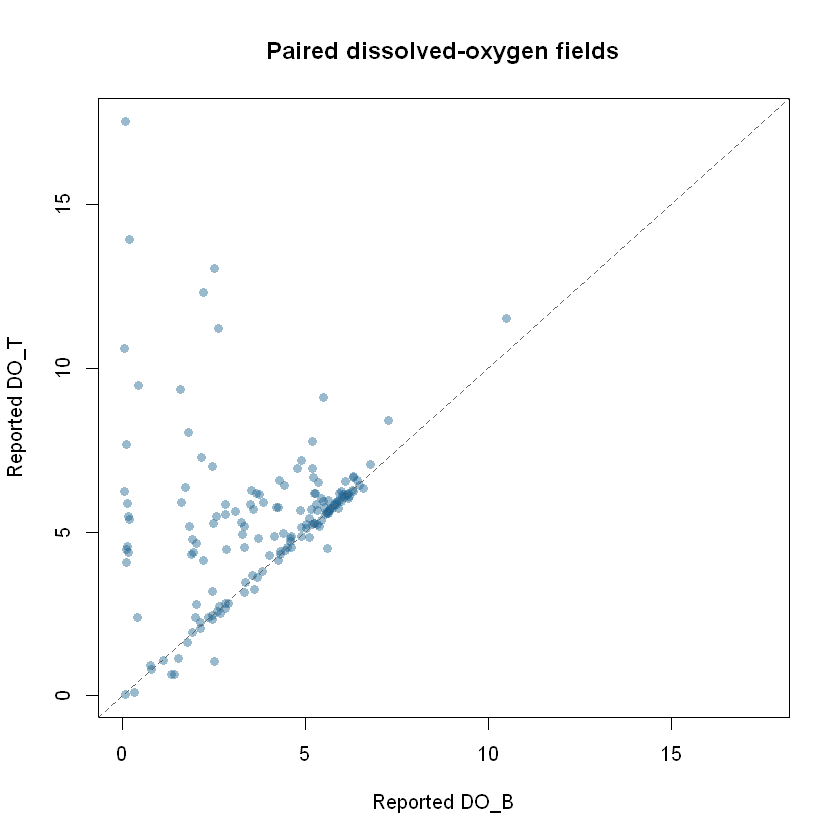

In [4]:
if (nrow(paired)) {
  limits <- range(c(paired$DO_T, paired$DO_B))
  plot(paired$DO_B, paired$DO_T, xlim = limits, ylim = limits,
       pch = 16, col = grDevices::rgb(0.11, 0.39, 0.57, 0.45),
       xlab = "Reported DO_B", ylab = "Reported DO_T",
       main = "Paired dissolved-oxygen fields")
  abline(0, 1, lty = 2, col = "gray40")
  cat(sprintf("%d of %d usable pairs have DO_T above DO_B.\n",
              sum(paired$DO_T > paired$DO_B), nrow(paired)))
} else {
  plot.new()
  text(0.5, 0.5, "No records have both oxygen fields")
}

## What this shows

The chart describes only rows with both measurements; the count table shows how much of the layer that covers. The source describes the **latest reviewed samples**, not a full station history. Units, detection limits, methods, and uneven station coverage need source review before environmental comparisons or policy use.